In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore') 

In [2]:
# loading the dataset 
data = pd.read_csv('../dataset/Tourism_Game_Park_Datasets.csv')
# Display the first few rows of the dataset
data.head()

,RecordID,Park,Animal,Visitors,TempC,RainfallMM,Season,Detected,ModelScore,VisitDate
0,1,Kibale,Elephant,32,30.6,125.0,Dry,Yes,0.86,2024-12-12
1,2,Kibale,Leopard,64,28,16.0,Dry,Yes,0.61,2024-09-15
2,3,Lake Mburo,Elephant,307,21.4,279.0,Wet,Yes,0.72,2024-05-22
3,4,Mgahinga,Chimpanzee,23,30.9,81.0,Wet,No,0.64,2024-04-20
4,5,Mgahinga,Gorilla,72,19.6,49.0,Wet,No,0.80,2024-01-23


In [3]:
# Check for missing values
data.isnull().sum()

RecordID      0
Park          0
Animal        1
Visitors      0
TempC         0
RainfallMM    1
Season        0
Detected      0
ModelScore    1
VisitDate     0
dtype: int64

In [4]:
#removing the missing values
data = data.dropna()

In [5]:
#cheacking whether the missing values have been removed or not
data.isnull().sum()

RecordID      0
Park          0
Animal        0
Visitors      0
TempC         0
RainfallMM    0
Season        0
Detected      0
ModelScore    0
VisitDate     0
dtype: int64

In [6]:
# checking for duplicate rows
data.duplicated().sum()

np.int64(7)

In [7]:
#  checking for wrong format of data in the dataset
# checking for wrong data type in the dataset
data.dtypes

RecordID          str
Park              str
Animal            str
Visitors          str
TempC             str
RainfallMM    float64
Season            str
Detected          str
ModelScore    float64
VisitDate         str
dtype: object

In [8]:
# fixingthe wrong data type in the dataset and wrong format of data in the dataset
#Convert Visitors from string to numeric
data['Visitors'] = pd.to_numeric(data['Visitors'], errors='coerce') 
#Convert TempC from string to numeric
data['TempC'] = pd.to_numeric(data['TempC'], errors='coerce')
#Convert VisitDate from string to date format
data['VisitDate'] = pd.to_datetime(data['VisitDate'], errors='coerce')

In [9]:
#Check the data types again
data.dtypes

RecordID                 str
Park                     str
Animal                   str
Visitors             float64
TempC                float64
RainfallMM           float64
Season                   str
Detected                 str
ModelScore           float64
VisitDate     datetime64[us]
dtype: object

In [10]:
#dropping the RecordID column as it does not contain useful information.
data = data.drop('RecordID', axis=1)

In [11]:
# Summary statistics of the dataset
data.describe()

,Visitors,TempC,RainfallMM,ModelScore,VisitDate
count,1496.000000,1495.000000,1497.000000,1497.000000,1495
mean,259.380348,26.268963,152.009352,0.747335,2024-07-06 23:42:39.732441
min,20.000000,18.000000,0.000000,0.500000,2024-01-01 00:00:00
25%,136.750000,21.950000,72.000000,0.630000,2024-04-01 12:00:00
50%,262.500000,26.200000,154.000000,0.740000,2024-07-13 00:00:00
75%,381.000000,30.300000,227.000000,0.860000,2024-10-10 00:00:00
max,500.000000,34.900000,300.000000,1.500000,2024-12-31 00:00:00
std,139.189754,4.890850,86.460741,0.138304,NaN


In [12]:
#checking  for have 2 missing temperatures.
data['TempC'].isnull().sum()

np.int64(2)

In [13]:
#checking for which rows have missing temperatures
data[data['TempC'].isnull()]

,Park,Animal,Visitors,TempC,RainfallMM,Season,Detected,ModelScore,VisitDate
40,Kibale,Gorilla,102.0,NaN,282.0,Wet,Yes,0.55,2024-12-19
180,Queen Elizabeth,Elephant,171.0,NaN,51.0,Dry,No,0.93,2024-11-12


In [14]:
# Fill missing TempC values with the average temperature
data['TempC'] = data['TempC'].fillna(data['TempC'].mean())

In [15]:
# ckeacking for missing values after filling
data['TempC'].isnull().sum()

np.int64(0)

In [16]:
#checking for all missing values after filling the missing values
data.isnull().sum()

Park          0
Animal        0
Visitors      1
TempC         0
RainfallMM    0
Season        0
Detected      0
ModelScore    0
VisitDate     2
dtype: int64

In [17]:
#Fix missing Visitors
data['Visitors'] = data['Visitors'].fillna(data['Visitors'].mean())
#Fix missing VisitDate
data[data['VisitDate'].isnull()]   

,Park,Animal,Visitors,TempC,RainfallMM,Season,Detected,ModelScore,VisitDate
140,Kidepo,Chimpanzee,95.0,31.4,1.0,Wet,Yes,0.98,NaT
160,Murchison Falls,Elephant,124.0,23.1,108.0,Dry,No,0.64,NaT


In [18]:
#sorting the by date
data = data.sort_values('VisitDate')
#Then fill missing dates
data['VisitDate'] = data['VisitDate'].ffill() 

In [19]:
#checking again after filling missing values
data['VisitDate'].isnull().sum()

np.int64(0)

In [20]:
#overall checking for missing values after filling the missing values
data.isnull().sum()

Park          0
Animal        0
Visitors      0
TempC         0
RainfallMM    0
Season        0
Detected      0
ModelScore    0
VisitDate     0
dtype: int64

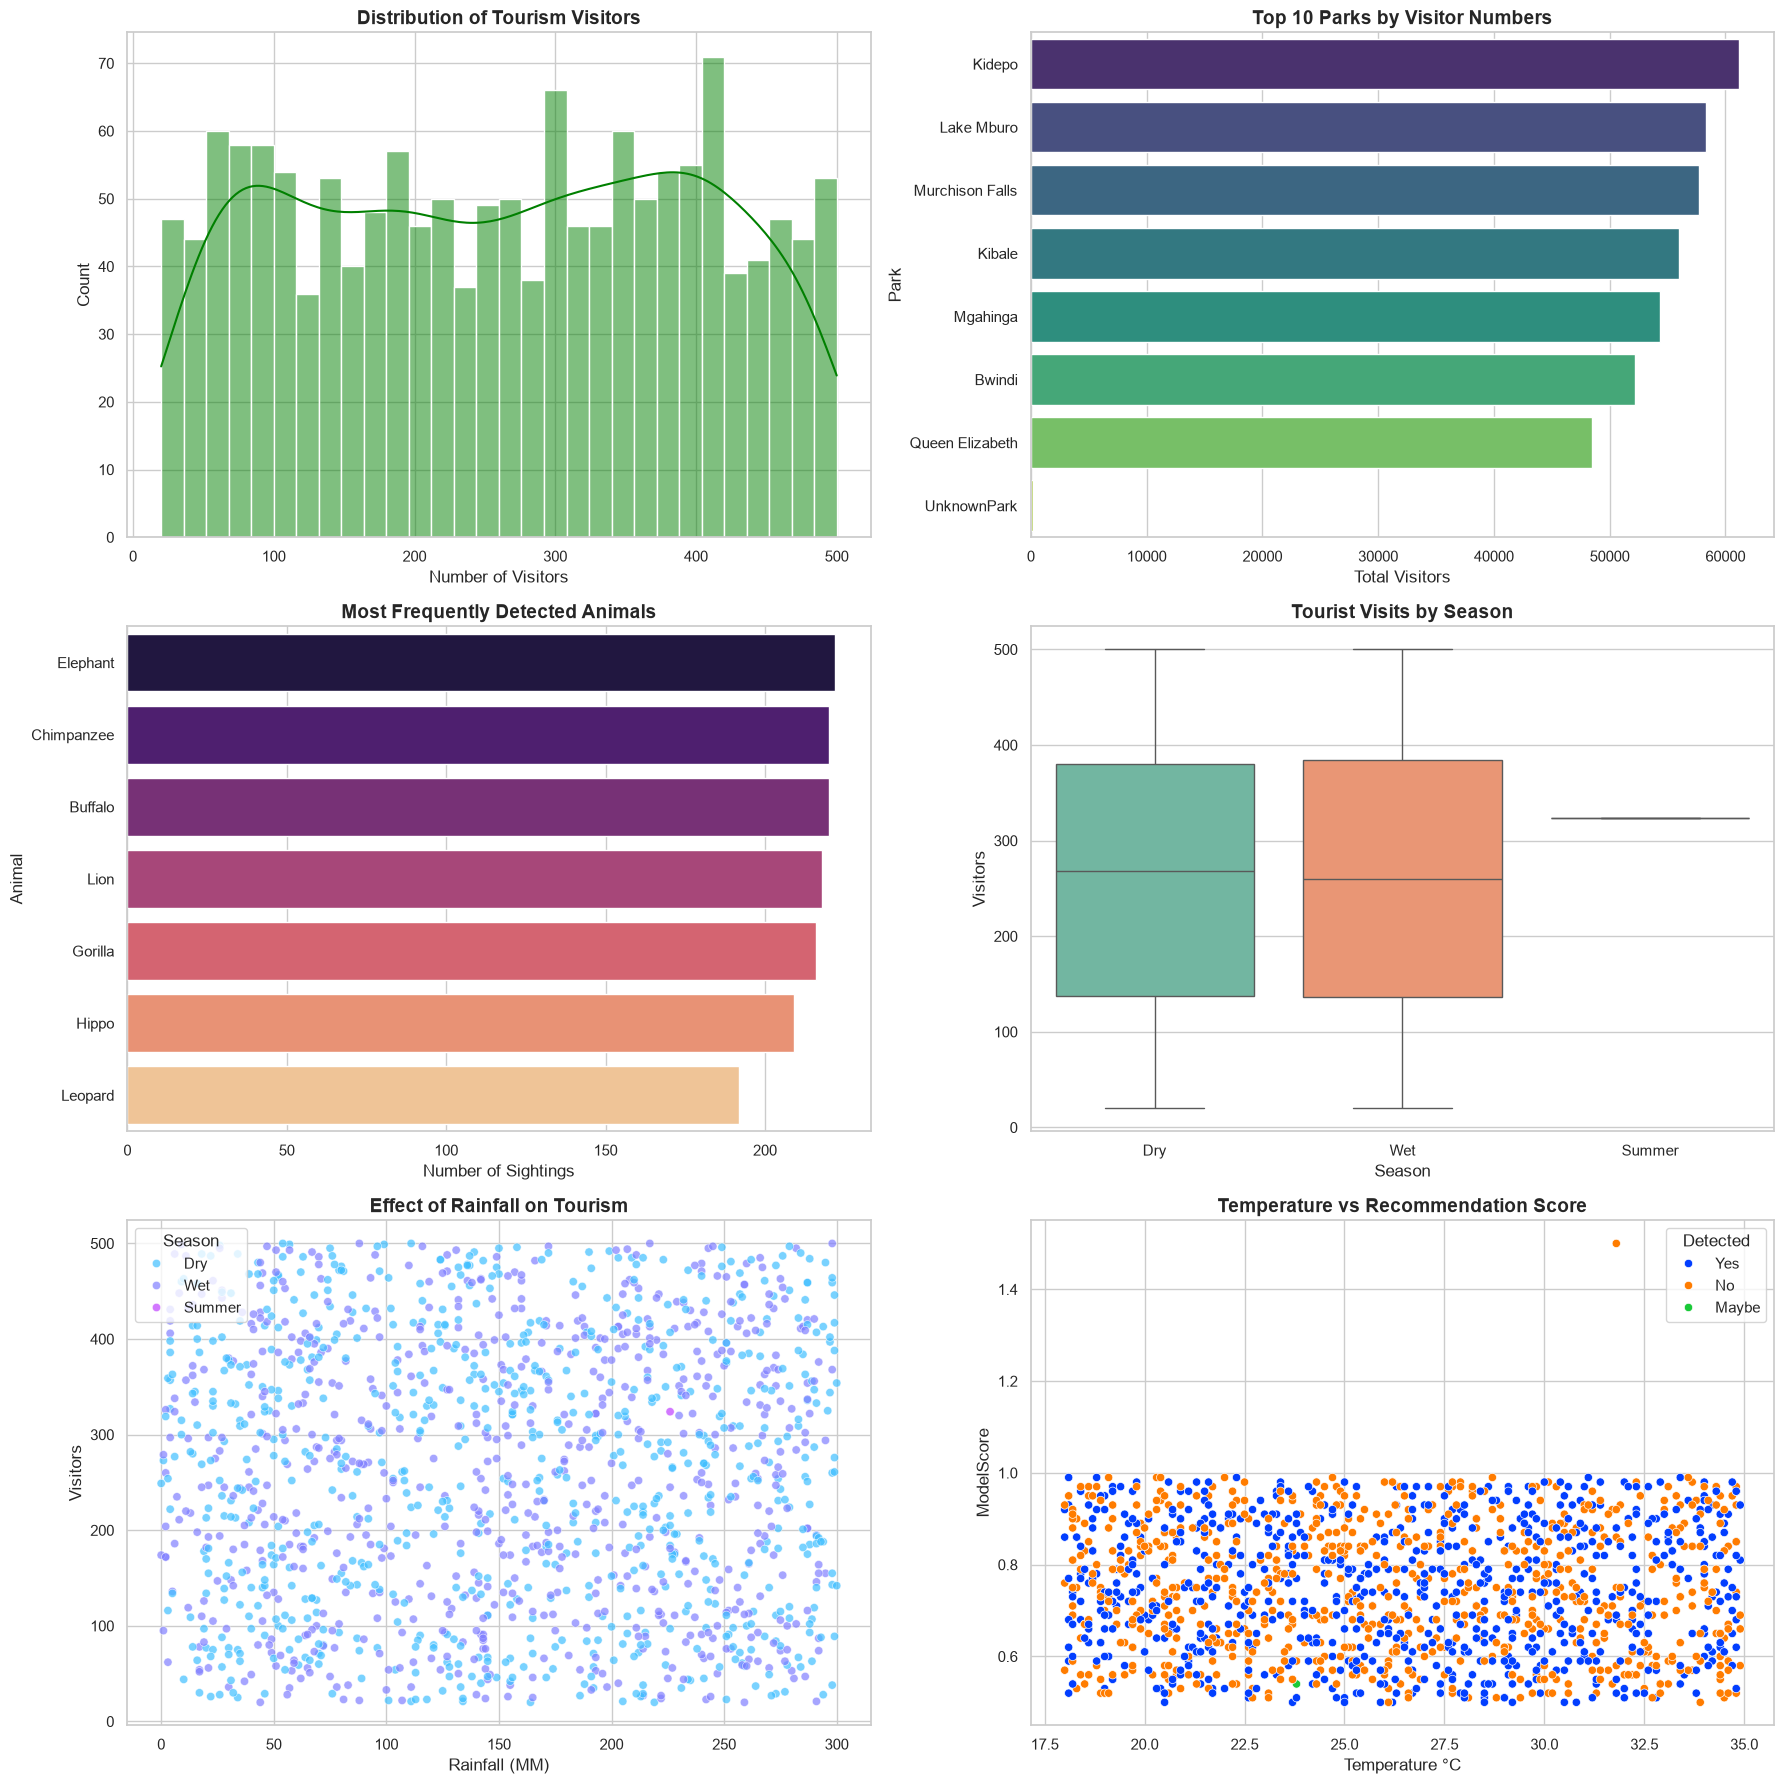

In [21]:
# =====================================
#   Data Visualization
# =====================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Better visualization style
sns.set_theme(style="whitegrid")


# Create multiple plots
fig, axes = plt.subplots(3, 2, figsize=(18, 18))


# -------------------------------------
# 1. Visitors Distribution
# -------------------------------------

sns.histplot(
    data=data,
    x="Visitors",
    bins=30,
    kde=True,
    color="green",
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Distribution of Tourism Visitors",
    fontsize=14,
    fontweight="bold"
)

axes[0,0].set_xlabel("Number of Visitors")


# -------------------------------------
# 2. Top Parks by Visitors
# -------------------------------------

park_visits = (
    data.groupby("Park")["Visitors"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


sns.barplot(
    x=park_visits.values,
    y=park_visits.index,
    palette="viridis",
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Top 10 Parks by Visitor Numbers",
    fontsize=14,
    fontweight="bold"
)

axes[0,1].set_xlabel("Total Visitors")
axes[0,1].set_ylabel("Park")


# -------------------------------------
# 3. Animal Detection Frequency
# -------------------------------------

animal_count = (
    data["Animal"]
    .value_counts()
    .head(10)
)


sns.barplot(
    x=animal_count.values,
    y=animal_count.index,
    palette="magma",
    ax=axes[1,0]
)


axes[1,0].set_title(
    "Most Frequently Detected Animals",
    fontsize=14,
    fontweight="bold"
)

axes[1,0].set_xlabel("Number of Sightings")


# -------------------------------------
# 4. Season vs Visitors
# -------------------------------------

sns.boxplot(
    data=data,
    x="Season",
    y="Visitors",
    palette="Set2",
    ax=axes[1,1]
)


axes[1,1].set_title(
    "Tourist Visits by Season",
    fontsize=14,
    fontweight="bold"
)


# -------------------------------------
# 5. Rainfall vs Visitors
# -------------------------------------

sns.scatterplot(
    data=data,
    x="RainfallMM",
    y="Visitors",
    hue="Season",
    palette="cool",
    alpha=0.7,
    ax=axes[2,0]
)


axes[2,0].set_title(
    "Effect of Rainfall on Tourism",
    fontsize=14,
    fontweight="bold"
)


axes[2,0].set_xlabel(
    "Rainfall (MM)"
)


# -------------------------------------
# 6. Temperature vs Model Score
# -------------------------------------

sns.scatterplot(
    data=data,
    x="TempC",
    y="ModelScore",
    hue="Detected",
    palette="bright",
    ax=axes[2,1]
)


axes[2,1].set_title(
    "Temperature vs Recommendation Score",
    fontsize=14,
    fontweight="bold"
)


axes[2,1].set_xlabel(
    "Temperature °C"
)


plt.tight_layout()


# Save visualization
plt.savefig(
    "Wildlife_Tourism_Data_Analysis.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

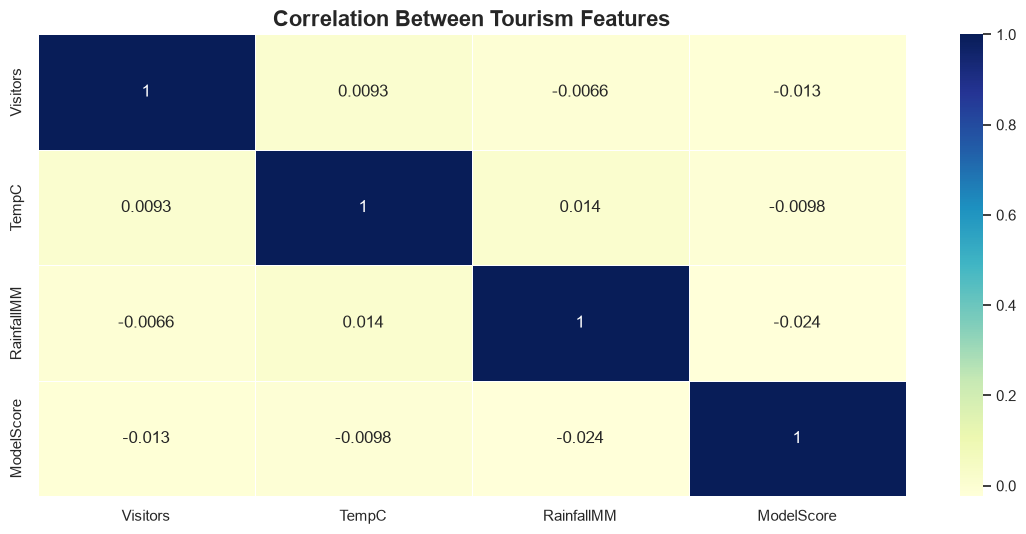

In [22]:
#correlation heatmap
plt.figure(figsize=(14,6))


numeric_data = data.select_dtypes(
    include=['float64','int64']
)


sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5
)


plt.title(
    "Correlation Between Tourism Features",
    fontsize=16,
    fontweight="bold"
)


plt.savefig(
    "Tourism_Feature_Correlation.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

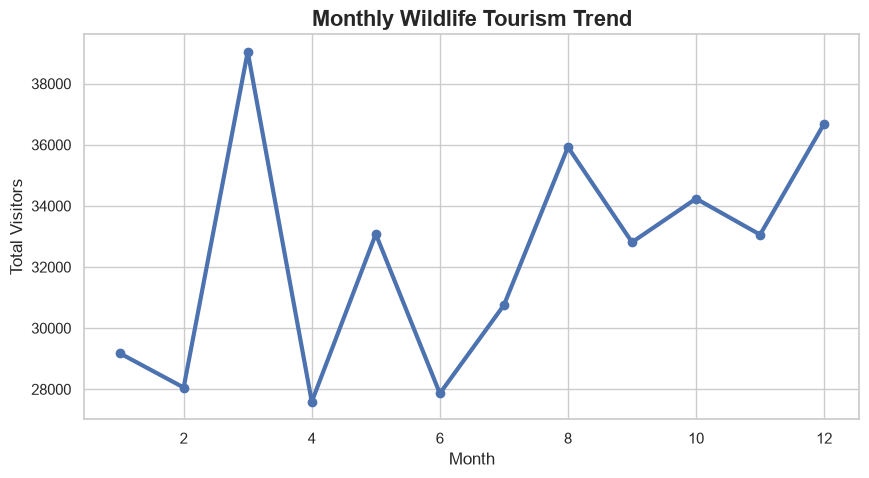

In [23]:
#Monthly Tourism Trend Visualization
data['Month'] = data['VisitDate'].dt.month


monthly = (
    data.groupby("Month")["Visitors"]
    .sum()
)


plt.figure(figsize=(10,5))


plt.plot(
    monthly.index,
    monthly.values,
    marker="o",
    linewidth=3
)


plt.title(
    "Monthly Wildlife Tourism Trend",
    fontsize=16,
    fontweight="bold"
)


plt.xlabel("Month")
plt.ylabel("Total Visitors")


plt.grid(True)


plt.savefig(
    "Monthly_Tourism_Trend.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [24]:
import pandas as pd

# Load original dataset
original_data = pd.read_csv(
    '../dataset/Tourism_Game_Park_Datasets.csv'
)

# Convert VisitDate correctly
original_data['VisitDate'] = pd.to_datetime(
    original_data['VisitDate'],
    format='mixed'
)

# Create a working copy
data_processed = original_data.copy()

# Check result
data_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   RecordID    1500 non-null   str           
 1   Park        1500 non-null   str           
 2   Animal      1499 non-null   str           
 3   Visitors    1500 non-null   str           
 4   TempC       1500 non-null   str           
 5   RainfallMM  1499 non-null   float64       
 6   Season      1500 non-null   str           
 7   Detected    1500 non-null   str           
 8   ModelScore  1499 non-null   float64       
 9   VisitDate   1500 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(2), str(7)
memory usage: 117.3 KB


In [25]:
#checking for missing values in the 'Animal' column
data_processed['Animal'].isnull().sum()

np.int64(1)

In [26]:
#Finding  the row with the missing value
data_processed[data_processed['Animal'].isnull()]
#Filling it with the most common animal
data_processed['Animal'].fillna(data_processed['Animal'].mode()[0], inplace=True)

0         Elephant
1          Leopard
2         Elephant
3       Chimpanzee
4          Gorilla
           ...    
1495       Leopard
1496    Chimpanzee
1497      Elephant
1498       Buffalo
1499    Chimpanzee
Name: Animal, Length: 1500, dtype: str

In [27]:
#confirming if am using the copied dataset
data_processed.head()
data_processed.info() 

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   RecordID    1500 non-null   str           
 1   Park        1500 non-null   str           
 2   Animal      1499 non-null   str           
 3   Visitors    1500 non-null   str           
 4   TempC       1500 non-null   str           
 5   RainfallMM  1499 non-null   float64       
 6   Season      1500 non-null   str           
 7   Detected    1500 non-null   str           
 8   ModelScore  1499 non-null   float64       
 9   VisitDate   1500 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(2), str(7)
memory usage: 117.3 KB


In [28]:
#feature engineering
# Convert VisitDate to datetime format
 # Convert VisitDate to datetime
data_processed['VisitDate'] = pd.to_datetime(
    data_processed['VisitDate'],
    format='mixed'
)

# Extract useful date features
data_processed['Year'] = data_processed['VisitDate'].dt.year
data_processed['Month'] = data_processed['VisitDate'].dt.month
data_processed['Day'] = data_processed['VisitDate'].dt.day
data_processed['Weekday'] = data_processed['VisitDate'].dt.weekday

# Remove original date
data_processed.drop(
    'VisitDate',
    axis=1,
    inplace=True
)

In [29]:
#encoding categorical variables
from sklearn.preprocessing import LabelEncoder

# Dictionary to store encoders
label_encoder = {}

# Your categorical columns
categorical_columns = [
    'Park',
    'Animal',
    'Season',
    'Detected'
]

# Encode each categorical column
for col in categorical_columns:
    le = LabelEncoder()
    
    data_processed[col + '_Encoded'] = le.fit_transform(
        data_processed[col]
    )
    
    # Store encoder for future predictions
    label_encoder[col] = le
    
    print(
        f'Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}'
    )

Encoded Park: {'Bwindi': np.int64(0), 'Kibale': np.int64(1), 'Kidepo': np.int64(2), 'Lake Mburo': np.int64(3), 'Mgahinga': np.int64(4), 'Murchison Falls': np.int64(5), 'Queen Elizabeth': np.int64(6), 'UnknownPark': np.int64(7)}
Encoded Animal: {'Buffalo': np.int64(0), 'Chimpanzee': np.int64(1), 'Elephant': np.int64(2), 'Gorilla': np.int64(3), 'Hippo': np.int64(4), 'Leopard': np.int64(5), 'Lion': np.int64(6), nan: np.int64(7)}
Encoded Season: {'Dry': np.int64(0), 'Summer': np.int64(1), 'Wet': np.int64(2)}
Encoded Detected: {'Maybe': np.int64(0), 'No': np.int64(1), 'Yes': np.int64(2)}


In [30]:
#Re-checking the missing values after encoding
data_processed.isnull().sum()

RecordID            0
Park                0
Animal              1
Visitors            0
TempC               0
RainfallMM          1
Season              0
Detected            0
ModelScore          1
Year                0
Month               0
Day                 0
Weekday             0
Park_Encoded        0
Animal_Encoded      0
Season_Encoded      0
Detected_Encoded    0
dtype: int64

In [31]:
#using the most common animal to fill the missing value in the 'Animal' column
data_processed['Animal'] = data_processed['Animal'].fillna(
    data_processed['Animal'].mode()[0]
)

In [32]:
#confirming that the missing value has been filled
data_processed['Animal'].isnull().sum()

np.int64(0)

In [33]:
#Fixing the  missing RainfallMM
data_processed['RainfallMM'] = data_processed['RainfallMM'].fillna(
    data_processed['RainfallMM'].mean()
)

In [34]:
#confirming that the missing value has been filled
data_processed['RainfallMM'].isnull().sum()

np.int64(0)

In [35]:
#Fix missing ModelScore
data_processed['ModelScore'] = data_processed['ModelScore'].fillna(
    data_processed['ModelScore'].mean()
)

In [36]:
#confirming that the missing value has been filled
data_processed['ModelScore'].isnull().sum()

np.int64(0)

In [37]:
#Removing  old encoded columns since they were created before fixing the missing values
data_processed = data_processed.drop(
    [
        'Park_Encoded',
        'Animal_Encoded',
        'Season_Encoded',
        'Detected_Encoded'
    ],
    axis=1
)

In [38]:
#Encoding  again
from sklearn.preprocessing import LabelEncoder

label_encoder = {}

categorical_columns = [
    'Park',
    'Animal',
    'Season',
    'Detected'
]


for col in categorical_columns:
    le = LabelEncoder()

    data_processed[col + '_Encoded'] = le.fit_transform(
        data_processed[col]
    )

    label_encoder[col] = le

    print(
        f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}"
    )

Encoded Park: {'Bwindi': np.int64(0), 'Kibale': np.int64(1), 'Kidepo': np.int64(2), 'Lake Mburo': np.int64(3), 'Mgahinga': np.int64(4), 'Murchison Falls': np.int64(5), 'Queen Elizabeth': np.int64(6), 'UnknownPark': np.int64(7)}
Encoded Animal: {'Buffalo': np.int64(0), 'Chimpanzee': np.int64(1), 'Elephant': np.int64(2), 'Gorilla': np.int64(3), 'Hippo': np.int64(4), 'Leopard': np.int64(5), 'Lion': np.int64(6)}
Encoded Season: {'Dry': np.int64(0), 'Summer': np.int64(1), 'Wet': np.int64(2)}
Encoded Detected: {'Maybe': np.int64(0), 'No': np.int64(1), 'Yes': np.int64(2)}


In [39]:
#checking for missing values after re-encoding
data_processed.isnull().sum()

RecordID            0
Park                0
Animal              0
Visitors            0
TempC               0
RainfallMM          0
Season              0
Detected            0
ModelScore          0
Year                0
Month               0
Day                 0
Weekday             0
Park_Encoded        0
Animal_Encoded      0
Season_Encoded      0
Detected_Encoded    0
dtype: int64

In [40]:
#saving the encoded labels
import os
import joblib

# Create models folder if it does not exist
os.makedirs("models", exist_ok=True)

# Save encoder
joblib.dump(
    label_encoder,
    "models/label_encoder.pkl"
) 

['models/label_encoder.pkl']

In [41]:
# Drop unnecessary columns after encoding

data_processed.drop(
    [
        'RecordID',     
        'Park',            
        'Animal',          
        'Season',         
        'Detected'         
    ],
    axis=1,
    inplace=True
)

# Display the processed dataset
print("Final Processed Dataset:")
data_processed.head()

Final Processed Dataset:


,Visitors,TempC,RainfallMM,ModelScore,Year,Month,Day,Weekday,Park_Encoded,Animal_Encoded,Season_Encoded,Detected_Encoded
0,32,30.6,125.0,0.86,2024,12,12,3,1,2,0,2
1,64,28,16.0,0.61,2024,9,15,6,1,5,0,2
2,307,21.4,279.0,0.72,2024,5,22,2,3,2,2,2
3,23,30.9,81.0,0.64,2024,4,20,5,4,1,2,1
4,72,19.6,49.0,0.80,2024,1,23,1,4,3,2,1


In [42]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)

# Features: remove the target column
X = data_processed.drop(
    'Detected_Encoded',
    axis=1
)

# Target variable
y = data_processed['Detected_Encoded']


# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Display split information

print("Classification: Predicting Wildlife Detection")

print("------------------------------")

print(f"Training samples: {X_train.shape[0]}")

print(f"Testing samples: {X_test.shape[0]}")

print(f"Number of features: {X_train.shape[1]}")

Classification: Predicting Wildlife Detection
------------------------------
Training samples: 1200
Testing samples: 300
Number of features: 11


In [43]:
#checking for columns still containing text
X_train.dtypes

Visitors              str
TempC                 str
RainfallMM        float64
ModelScore        float64
Year                int32
Month               int32
Day                 int32
Weekday             int32
Park_Encoded        int64
Animal_Encoded      int64
Season_Encoded      int64
dtype: object

In [44]:
# Convert Visitors and TempC from string to numeric

data_processed['Visitors'] = pd.to_numeric(
    data_processed['Visitors'],
    errors='coerce'
)

data_processed['TempC'] = pd.to_numeric(
    data_processed['TempC'],
    errors='coerce'
)

In [45]:
# Check missing values before filling
print("Missing values before fixing:")
print(data_processed[['Visitors', 'TempC']].isnull().sum())


# Convert Visitors and TempC to numeric (if not already)
import pandas as pd

data_processed['Visitors'] = pd.to_numeric(
    data_processed['Visitors'],
    errors='coerce'
)

data_processed['TempC'] = pd.to_numeric(
    data_processed['TempC'],
    errors='coerce'
)


# Fill missing Visitors using the mean value
data_processed['Visitors'] = data_processed['Visitors'].fillna(
    data_processed['Visitors'].mean()
)


# Fill missing Temperature using the mean value
data_processed['TempC'] = data_processed['TempC'].fillna(
    data_processed['TempC'].mean()
)


# Check missing values after filling
print("\nMissing values after fixing:")
print(data_processed[['Visitors', 'TempC']].isnull().sum())


# Check data types
print("\nData types after fixing:")
print(data_processed[['Visitors', 'TempC']].dtypes)

Missing values before fixing:
Visitors    1
TempC       2
dtype: int64

Missing values after fixing:
Visitors    0
TempC       0
dtype: int64

Data types after fixing:
Visitors    float64
TempC       float64
dtype: object


In [46]:
# Check complete dataset information
data_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Visitors          1500 non-null   float64
 1   TempC             1500 non-null   float64
 2   RainfallMM        1500 non-null   float64
 3   ModelScore        1500 non-null   float64
 4   Year              1500 non-null   int32  
 5   Month             1500 non-null   int32  
 6   Day               1500 non-null   int32  
 7   Weekday           1500 non-null   int32  
 8   Park_Encoded      1500 non-null   int64  
 9   Animal_Encoded    1500 non-null   int64  
 10  Season_Encoded    1500 non-null   int64  
 11  Detected_Encoded  1500 non-null   int64  
dtypes: float64(4), int32(4), int64(4)
memory usage: 117.3 KB


In [47]:
#Check your class distribution
data_processed['Detected_Encoded'].value_counts()

Detected_Encoded
2    751
1    748
0      1
Name: count, dtype: int64

In [48]:
# Check current distribution
print("Before correction:")
print(data_processed['Detected_Encoded'].value_counts())


data_processed['Detected_Encoded'] = data_processed['Detected_Encoded'].replace(
    {
        0: 0,   # Maybe becomes No
        1: 0,   # No remains No
        2: 1    # Yes becomes Yes
    }
)


# Check new distribution
print("\nAfter correction:")
print(data_processed['Detected_Encoded'].value_counts())

Before correction:
Detected_Encoded
2    751
1    748
0      1
Name: count, dtype: int64

After correction:
Detected_Encoded
1    751
0    749
Name: count, dtype: int64


In [49]:
#Train-test split after class correction
from sklearn.model_selection import train_test_split

# Features
X = data_processed.drop(
    'Detected_Encoded',
    axis=1
)

# Target
y = data_processed['Detected_Encoded']


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])


# Check class distribution after splitting
print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 1200
Testing samples: 300
Number of features: 11

Training target distribution:
Detected_Encoded
1    601
0    599
Name: count, dtype: int64

Testing target distribution:
Detected_Encoded
0    150
1    150
Name: count, dtype: int64


In [50]:
#Models 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Define models

models = {
    "Decision Tree Classifier": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}


results = {}


# Train and evaluate

for name, model in models.items():

    print("\n==============================")
    print(name)
    print("==============================")


    # Training
    model.fit(
        X_train,
        y_train
    )


    # Prediction
    y_pred = model.predict(
        X_test
    )


    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )


    results[name] = {
        "model": model,
        "accuracy": accuracy
    }


    print("Accuracy:", round(accuracy,4))


    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred
        )
    )


    print("\nConfusion Matrix:")
    print(
        confusion_matrix(
            y_test,
            y_pred
        )
    )


Decision Tree Classifier
Accuracy: 0.5167

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.55      0.53       150
           1       0.52      0.48      0.50       150

    accuracy                           0.52       300
   macro avg       0.52      0.52      0.52       300
weighted avg       0.52      0.52      0.52       300


Confusion Matrix:
[[83 67]
 [78 72]]

Random Forest Classifier
Accuracy: 0.5433

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.59      0.57       150
           1       0.55      0.49      0.52       150

    accuracy                           0.54       300
   macro avg       0.54      0.54      0.54       300
weighted avg       0.54      0.54      0.54       300


Confusion Matrix:
[[89 61]
 [76 74]]


In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate Random Forest metrics

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    zero_division=0
)


# Create final comparison table

model_comparison = pd.DataFrame({

    "Accuracy": [
        dt_accuracy,
        rf_accuracy
    ],

    "Precision": [
        dt_precision,
        rf_precision
    ],

    "Recall": [
        dt_recall,
        rf_recall
    ],

    "F1-score": [
        dt_f1,
        rf_f1
    ]

},
index=[
    "Decision Tree",
    "Random Forest"
])


print(model_comparison)

NameError: name 'rf_predictions' is not defined

<Figure size 1000x600 with 0 Axes>

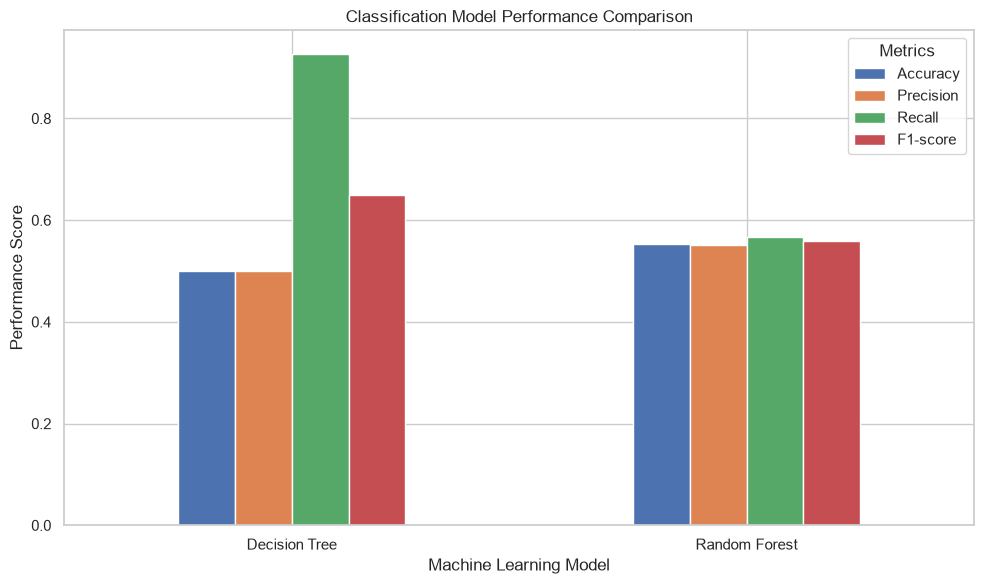

In [ ]:
#visualization of the results
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# Model performance comparison visualization

plt.figure(figsize=(10,6))


model_comparison.plot(
    kind='bar',
    figsize=(10,6)
)


plt.title(
    "Classification Model Performance Comparison"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Performance Score"
)


plt.xticks(
    rotation=0
)


plt.legend(
    title="Metrics"
)


plt.tight_layout()


# Save image

plt.savefig(
    "model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

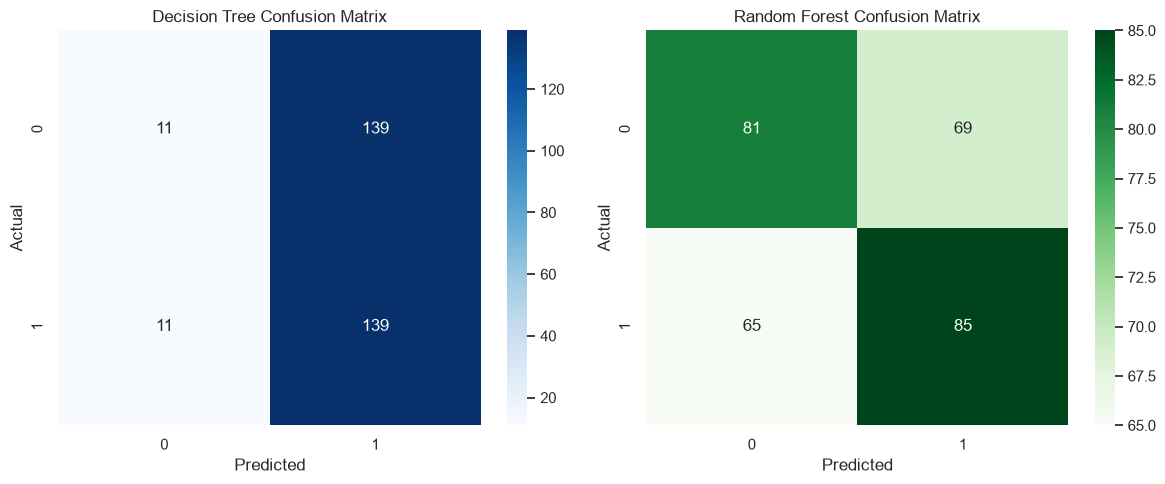

In [ ]:
#visualize the confusion matrices for both models
from sklearn.metrics import confusion_matrix


# Create confusion matrices

dt_cm = confusion_matrix(
    y_test,
    dt_predictions
)


rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)



# Plot

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)



# Decision Tree

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)


axes[0].set_title(
    "Decision Tree Confusion Matrix"
)

axes[0].set_xlabel(
    "Predicted"
)

axes[0].set_ylabel(
    "Actual"
)



# Random Forest

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1]
)


axes[1].set_title(
    "Random Forest Confusion Matrix"
)

axes[1].set_xlabel(
    "Predicted"
)

axes[1].set_ylabel(
    "Actual"
)



plt.tight_layout()


plt.savefig(
    "confusion_matrix_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

                   Decision Tree  Random Forest
Training Accuracy         0.5425       0.944167
Testing Accuracy          0.5000       0.553333


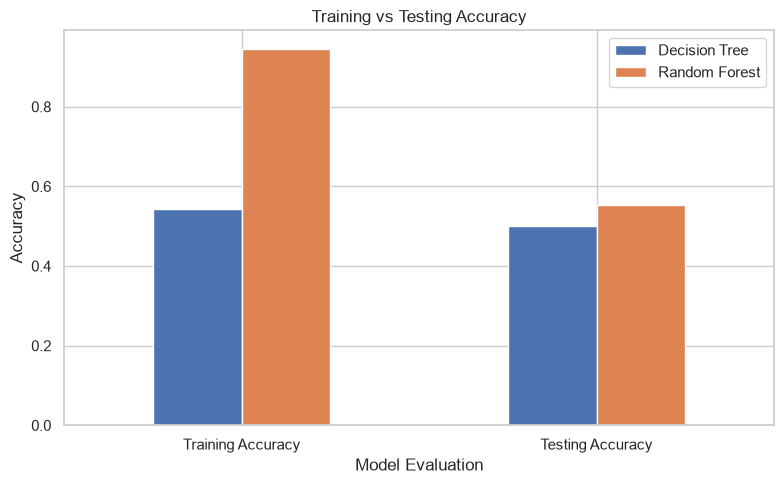

In [ ]:
# Calculate training and testing accuracy

training_testing_accuracy = pd.DataFrame({

    "Decision Tree":[
        dt_model.score(X_train,y_train),
        dt_model.score(X_test,y_test)
    ],

    "Random Forest":[
        rf_model.score(X_train,y_train),
        rf_model.score(X_test,y_test)
    ]

},
index=[
    "Training Accuracy",
    "Testing Accuracy"
])


print(training_testing_accuracy)



# Plot

training_testing_accuracy.plot(
    kind="bar",
    figsize=(8,5)
)


plt.title(
    "Training vs Testing Accuracy"
)


plt.ylabel(
    "Accuracy"
)


plt.xlabel(
    "Model Evaluation"
)


plt.xticks(
    rotation=0
)


plt.tight_layout()


plt.savefig(
    "training_testing_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
#sabing the best model
# ==========================================
# Save Final Random Forest Model
# ==========================================

import os
import joblib


# Create models folder if it does not exist

if not os.path.exists("models"):
    os.makedirs("models")


# Save the trained Random Forest model

joblib.dump(
    rf_model,
    "models/wildlife_detection_random_forest.pkl"
)


print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [ ]:
import joblib

feature_columns = X_train.columns.tolist()


joblib.dump(
    feature_columns,
    "models/feature_columns.pkl"
)


print("Feature columns saved")

Feature columns saved


In [ ]:
import joblib


model = joblib.load(
    "models/wildlife_detection_random_forest.pkl"
)


print(model)

RandomForestClassifier(max_depth=8, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=200, random_state=42)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Predictions
rf_tuned_predictions = rf_model.predict(X_test)


# Metrics

accuracy = accuracy_score(
    y_test,
    rf_tuned_predictions
)

precision = precision_score(
    y_test,
    rf_tuned_predictions
)

recall = recall_score(
    y_test,
    rf_tuned_predictions
)

f1 = f1_score(
    y_test,
    rf_tuned_predictions
)


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


# Overfitting check

train_accuracy = rf_model.score(
    X_train,
    y_train
)

test_accuracy = rf_model.score(
    X_test,
    y_test
)


print("\nTraining Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Accuracy: 0.5533333333333333
Precision: 0.551948051948052
Recall: 0.5666666666666667
F1-score: 0.5592105263157895

Training Accuracy: 0.9441666666666667
Testing Accuracy: 0.5533333333333333


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, rf_tuned_predictions))

print(classification_report(y_test, rf_tuned_predictions))

[[81 69]
 [65 85]]
              precision    recall  f1-score   support

           0       0.55      0.54      0.55       150
           1       0.55      0.57      0.56       150

    accuracy                           0.55       300
   macro avg       0.55      0.55      0.55       300
weighted avg       0.55      0.55      0.55       300



In [ ]:
import os
import joblib


# Ensure models folder exists

if not os.path.exists("models"):
    os.makedirs("models")


# Replace the old Random Forest model

joblib.dump(
    rf_model,
    "models/wildlife_detection_random_forest.pkl"
)


print("Final Random Forest model replaced successfully!")

Final Random Forest model replaced successfully!


In [ ]:
# Load the saved model again to confirm

loaded_model = joblib.load(
    "models/wildlife_detection_random_forest.pkl"
)


print(loaded_model)

RandomForestClassifier(max_depth=8, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=200, random_state=42)


In [ ]:
# Save feature names/order

feature_columns = X_train.columns.tolist()


joblib.dump(
    feature_columns,
    "models/feature_columns.pkl"
)


print("Feature columns saved successfully!")
print(feature_columns)

Feature columns saved successfully!
['Visitors', 'TempC', 'RainfallMM', 'ModelScore', 'Year', 'Month', 'Day', 'Weekday', 'Park_Encoded', 'Animal_Encoded', 'Season_Encoded']


In [ ]:
import os

print(os.listdir("models"))

['feature_columns.pkl', 'label_encoder.pkl', 'wildlife_detection_random_forest.pkl']


In [ ]:
import joblib


# Load saved files

model = joblib.load(
    "models/wildlife_detection_random_forest.pkl"
)

encoders = joblib.load(
    "models/label_encoder.pkl"
)

features = joblib.load(
    "models/feature_columns.pkl"
)


print("Model loaded successfully:")
print(model)

print("\nEncoders loaded:")
print(encoders.keys())

print("\nFeature order:")
print(features)

Model loaded successfully:
RandomForestClassifier(max_depth=8, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=200, random_state=42)

Encoders loaded:
dict_keys(['Park', 'Animal', 'Season', 'Detected'])

Feature order:
['Visitors', 'TempC', 'RainfallMM', 'ModelScore', 'Year', 'Month', 'Day', 'Weekday', 'Park_Encoded', 'Animal_Encoded', 'Season_Encoded']
